QUANTUM CIRCUIT:

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

MEASUREMENT RESULTS AFTER 1000 RUNS:

State |00> occurred 492 times (49.2%)
State |01> occurred 0 times (0.0%)
State |10> occurred 0 times (0.0%)
State |11> occurred 508 times (50.8%)

EXPECTED RESULT:
|00> should occur about 50% of the time.
|11> should occur about 50% of the time.
|01> and |10> should occur about 0% of the time.

PHYSICS MEANING:
Both qubits become entangled.
Their individual measurement outcomes are random,
but the two qubits always give matching results: 00 or 11.


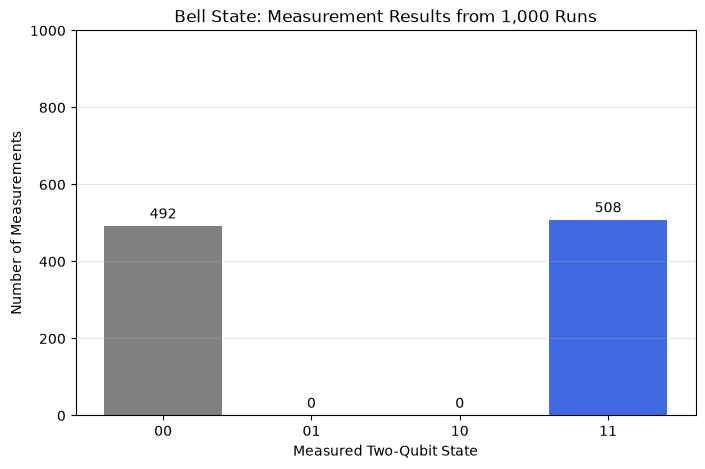

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

qc = QuantumCircuit(2, 2)

qc.h(0)
qc.cx(0, 1)

qc.measure(0, 0)
qc.measure(1, 1)

print("QUANTUM CIRCUIT:\n")
print(qc.draw())

simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()
counts = result.get_counts()

all_results = {
    "00": counts.get("00", 0),
    "01": counts.get("01", 0),
    "10": counts.get("10", 0),
    "11": counts.get("11", 0)}

print("\nMEASUREMENT RESULTS AFTER 1000 RUNS:\n")

for state, number in all_results.items():
    percentage = (number / 1000) * 100
    print(f"State |{state}> occurred {number} times ({percentage:.1f}%)")

print("\nEXPECTED RESULT:")
print("|00> should occur about 50% of the time.")
print("|11> should occur about 50% of the time.")
print("|01> and |10> should occur about 0% of the time.")

print("\nPHYSICS MEANING:")
print("Both qubits become entangled.")
print("Their individual measurement outcomes are random,")
print("but the two qubits always give matching results: 00 or 11.")

states = list(all_results.keys())
values = list(all_results.values())
plt.figure(figsize=(8, 5))
bars = plt.bar(states, values, color=["gray", "gray", "gray", "royalblue"])
plt.title("Bell State: Measurement Results from 1,000 Runs")
plt.xlabel("Measured Two-Qubit State")
plt.ylabel("Number of Measurements")
plt.ylim(0, 1000)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 20,
        str(value),
        ha="center" )
plt.show()